<a href="https://www.nvidia.com/dli"> <img src="images/nvidia_header.png" style="margin-left: -30px; width: 300px; float: left;"> </a>

# Deploying a Deep Research Agent with NVIDIA AI-Q

Welcome to the final notebook in the **NVIDIA AI-Q Research Assistant Blueprint** Deep Learning Institute (DLI) course!

In the previous notebooks, you learned how to deploy reasoning models ([Notebook 02](02-Deploy-NIM.ipynb)) and build a complete RAG system ([Notebook 03](03-Deploy-RAG.ipynb)). Now you'll bring it all together by deploying a **deep research agent**—an autonomous AI system that can conduct comprehensive, multi-step research across multiple sources, plan its investigations, and generate detailed reports supported by citations.

## Video Walkthrough

Execute the cell below to load the video of instructor Edward Li working through this notebook. 

**Note:** The ports used in the video have since been updated (``aira-frontend`` updated from 3001 to 3000; ``aira-backend`` updated from 8051 to 3838).

In [ ]:
%%html
<video controls width="800">
 <source src="https://d36m44n9vdbmda.cloudfront.net/assets/s-fx-40-v1/04-deploy-researcher-v1.mp4" type="video/mp4">
 <track src="transcripts/04-deploy-researcher-transcript.vtt"
       kind="subtitles" srclang="en" label="English" default>
 Sorry, your browser does not support embedded videos.
</video>

## 🎯 Learning Objectives

By the end of this notebook, you will:

1. **Understand Deep Research**: Learn what deep research is and how it differs from traditional search and simple RAG systems
2. **Master Agentic Workflows**: Explore how AI agents plan, execute, and iterate on complex research tasks
3. **Deploy the AI-Q Blueprint**: Set up a complete deep research system using NVIDIA-hosted endpoints
4. **Interact with the System**: Create research plans, provide human feedback, and generate comprehensive reports
5. **Understand Multi-Source Research**: See how the agent combines RAG, web search, and reasoning for thorough investigations

## 📦 The Blueprint: AI-Q Research Assistant

This notebook guides you through deploying a complete enterprise-grade Deep Research Agent powered by NVIDIA NIMs:

**Core Components:**
- **NVIDIA Nemotron Reasoning Model**: You have explored this in depth in [Notebook 02](02-Deploy-NIM.ipynb)
- **NVIDIA RAG Blueprint**: You have explored this in depth in [Notebook 03](03-Deploy-RAG.ipynb)
- **AIRA Backend**: The agent implementation for the deep research assistant
- **AIRA Frontend**: The frontend implementation for users to interact with the deep research assistant

**Supported Features:**
- **Deep Research:** Given a report topic and desired report structure, an agent (1) creates a report plan, (2) searches data sources for answers, (3) writes a report, (4) reflects on gaps in the report for further queries, (5) finishes a report with a list of sources.
- **Parallel Search:** During the research phase, multiple research questions are searched in parallel. For each query, the RAG service is consulted and an LLM-as-a-judge is used to check the relevancy of the results. If more information is needed, a fallback web search is performed. This search approach ensures internal documents are given preference over generic web results while maintaining accuracy. Performing query search in parallel allows for many data sources to be consulted in an efficient manner.
- **Human-in-the-loop:** Human feedback on the report plan, interactive report edits, and Q&A with the final report.
- **Data Sources:** Integration with the NVIDIA RAG blueprint to search multimodal documents with text, charts, and tables. Optional web search through Tavily.
- **Demo Web Application:** Frontend web application showcasing end-to-end use of the AI-Q Research Assistant.

## 📖 Table of Contents

| Section | Topic | Learning Goals |
|-------------------------|----------------------|----------------------|
| **1** | What is Deep Research? | Understand what deep research is and how those systems work  |
| **2** | Deploy the AI-Q Research Assistant | Use NVIDIA-hosted endpoints to deploy the AI-Q Research Assistant |
| **3** | Populate Knowledge Base with Sample Data | Learn how to ingest sample data into the deep research agent |
| **4** | Conduct Deep Research: A Walkthrough | Step-by-step walkthrough on how a query is processed by the agent |
| **5** | Cleanup: Stopping Services | Explore how to stop and clean up the deep research agent |
| **6** | (Optional) Local / On-Prem Deployment | Learn how to transition from hosted to local endpoints |

---

## 1. What is Deep Research?

**Deep Research** is an advanced AI capability that generates comprehensive reports by autonomously conducting multi-step online and offline research. Unlike a simple search, it involves the agentic reasoning and synthesis of information from a variety of sources, including the web and uploaded files, to answer a complex prompt. The result is a detailed, verified, and well-grounded output that goes beyond a typical search query for question-answering or a document lookup, often taking minutes to complete. Let's explore more about these differences. 

### 1.1 Traditional Search vs. Deep Research

While traditional search and deep research can both be done online using traditional search engines, offline using private databases, or a mixture of both, deep research agents uniquely utilize agentic reasoning and dynamic tool-calling to synthesize, generate, and complete more complex, multi-step tasks. Here is a more detailed breakdown: 

| Feature | Traditional Search | Deep Research with AI-Q |
|-------------------|-------------------------|-------------------------|
| **Primary Purpose** | Retrieving quick, factual information based on keywords | Conducting multi-step, in-depth analysis and synthesizing information from multiple sources into a single report |
| **Process** | **Matches keywords** from a query to existing documents and returns a set of ranked links or a brief summary of all retrieved sources in a single shot | Breaks down a complex query into sub-queries, creates a plan, searches across public and private sources, incorporates human-in-the-loop feedback, then reasons over gathered data iteratively to create a report |
| **Output** | A list of links to sources, often accompanied by a quick summary of all sources | A structured, detailed, and well-cited report in any user-specified organization structure. |
| **Timeframe** | Very fast, often delivering results in seconds | Slower, taking several minutes to complete its analysis |
| **Best For** | Quick fact retrieval, simple lookups, or when you know exactly what you are looking for | Complex, multi-faceted inquiries that require depth, technical or domain-specific understanding, synthesis of sources, and/or a report with custom structure.  |
| **Example Query** | How much revenue did AMZN generate in Q2 2024?  | Summarize the financial earnings for Amazon over the past few quarters. Focus on the financial performance, trends and patterns, growth drivers, and future outlook. |

### 1.2 How Deep Research Works

The AI-Q Research Assistant implements deep research through an **agentic workflow**, an automated process where AI agents autonomously make decisions, take actions, and adapt to achieve a goal or complete a task, rather than requiring constant human direction:

```
1. Research Planning Phase
   ├─ User provides topic and desired report structure
   ├─ Agent analyzes requirements and creates research plan
   └─ Human reviews and approves/modifies plan

2. Parallel Investigation Phase
   ├─ RAG Search: Queries your private document collections
   ├─ Web Search: Gathers current information from the internet (optional)
   └─ Multi-source synthesis: Combines findings from all sources

3. Report Generation Phase
   ├─ Agent drafts comprehensive report with citations
   ├─ Deep dives into specific topics
   ├─ Source traceability for verification
   └─ Final report includes sources from both RAG and web

4. Interactive Refinement Phase
   ├─ User Q&A with the completed report
   └─ User can request to refine sections
```

### 1.3 Understanding Deep Research Types and Approaches

Within the field of deep research, **DeepResearch-Bench**, a comprehensive benchmark for evaluating AI research systems, distinguishes between two fundamentally different approaches: **LLMs with Search Tools** and traditional **Deep Research Agents**. Understanding this distinction helps explain why AI-Q's architecture is enterprise-ready.

**Note:** Throughout this course, we often use 'deep research agent' as a general term for systems that perform autonomous research (rather than the technical DeepResearch-Bench definition in this section). However, using the DeepResearch-Bench taxonomy, the AI-Q research assistant is technically classified as an 'LLM with Search Tools'—a more enterprise-appropriate architecture that prioritizes your private data as we'll see below.

#### 🔍 LLMs with Search Tools

LLMs with search tools is a classification of deep research by DeepResearch-Bench that **performs targeted web searches (1-5 queries)** to augment responses with up-to-date and/or domain-specific information. The key design principle: **web search functions as an enhancement layer** alongside private enterprise data. The system generates queries external sources reactively, iterates selectively, and incorporates relevant information into its response.

**Core approach:** Private data first (via RAG), web search as strategic supplement when needed, followed by reflection and refinement.

#### 🤖 Traditional Deep Research Agents  

Deep Research Agents is a classification of deep research by DeepResearch-Bench that autonomously **orchestrate multistep web exploration (10-50+ queries)** to transform vast amounts of online information into analyst-grade reports. They conduct multiple rounds of searches, identify knowledge gaps, and focus on seeking information primarily through proactive exploration.

**Core approach:** Autonomous web research strategy with iterative refinement and gap identification.

#### 🎯 Key Differences

| Aspect | LLMs with Search Tools | Traditional Deep Research Agents |
|--------|----------------------|---------------------|
| **Primary Data Source** | **Private enterprise data (RAG)** | Public web information |
| **Search Role** | **Enhancement layer** for private data | Core autonomous research capability |
| **Search Behavior** | **Reactive** - searches when needed | **Proactive** - autonomous exploration |
| **Search Volume** | Targeted (1-5 queries) | Extensive (10-50+ queries) |
| **Enterprise Fit** | **Production-ready** for corporate use | Research/experimental use cases |
| **Data Governance** | **Private data prioritized**, web as supplement | Web-first approach |
| **Primary Use Case** | **Answering questions using internal knowledge** | Deep web research synthesis |

#### 🏆 AI-Q and Enterprise Readiness

**The AI-Q Research Assistant is an LLM with Search Tools** (per DeepResearch-Bench categorization), and this architecture makes it **enterprise-ready** for production deployments.

**Why This Works for Enterprises:**

The **reactive nature of web search** is a strategic advantage:

✅ **Private Data First**: Your internal documents (RAG) are the foundation; web search enhances rather than replaces  
✅ **Controlled Behavior**: Predictable, bounded searches rather than autonomous exploration  
✅ **Data Governance**: Private enterprise data remains primary; external searches are supplementary  
✅ **Cost Efficient**: Targeted searches and selective iteration keep API costs manageable  
✅ **Production-Ready**: Reliable behavior suitable for corporate deployments  

**How AI-Q Works:**

```
Your Research Request
  ↓
RAG Search (Primary): Queries your private document collections
  ↓
Enhancement Layer (Optional): Web search supplements when beneficial
  ↓
Synthesis: Combines internal + external sources
  ↓
Result: Report grounded in YOUR data, enhanced with external context
```

**Bottom Line:** AI-Q prioritizes your private data while strategically enhancing responses with external information. This reactive, controlled approach ensures web search serves your business needs. For enterprises that need to answer questions using their own data first, with web search as a strategic enhancement, this architecture is the right choice!

### 🏗️ 1.4 What You'll Deploy

This notebook deploys the complete **NVIDIA AI-Q Research Assistant Blueprint**, which builds on top of the RAG system from Notebook 03:

**From Previous Notebooks (Already Familiar):**
- RAG Pipeline (Notebook 03): Vector database, document ingestion, retrieval services
- Reasoning Model (Notebook 02): Nemotron reasoning LLM powering the agent for planning and synthesis

**New Components in This Notebook:**
- **AI-Q Backend**: Agentic orchestration engine that coordinates research workflows
- **AI-Q Frontend**: Interactive web interface for research planning and report generation
- **AI-Q Agent**
  - **Multi-Source Integration**: Combines RAG + Web Search (Tavily) for comprehensive research
  - **Research Planner**: Creates structured investigation plans with human approval
  - **Report Generator**: Synthesizes findings into formatted, cited documents

**Key Capabilities**

- **Multi-Step Reasoning**: Uses Nemotron reasoning models to break down complex research questions  
- **Human-in-the-Loop**: Allows you to review and guide the research plan  
- **Parallel Research**: Simultaneously searches internal documents (RAG) and web sources  
- **Source Attribution**: Every claim is linked back to specific documents or URLs  
- **Iterative Refinement**: Update drafts through conversational Q&A  
- **Multi-Modal Understanding**: Processes text, images, tables, and charts from documents  

**System Architecture:**

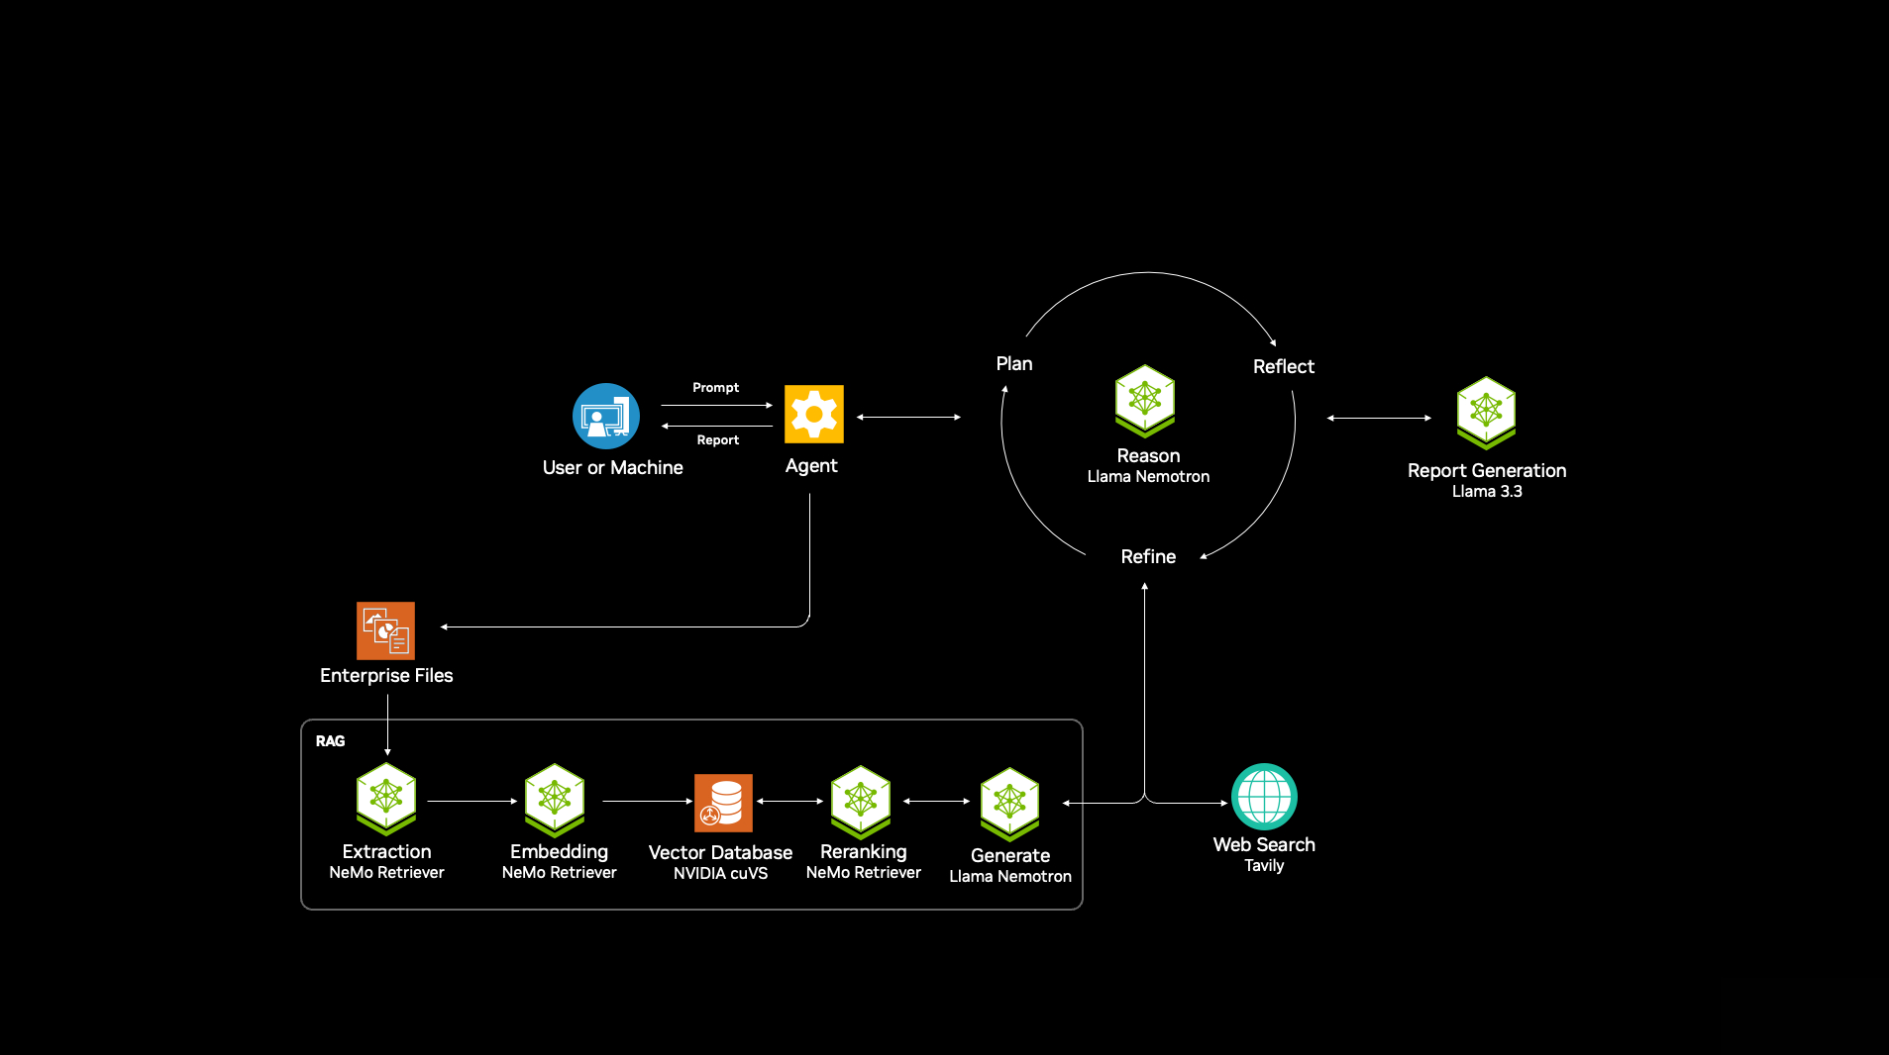

Let's build your deep research agent!


---

## 2. Deploy the AI-Q Research Assistant

Now that you understand what deep research is and how it differs from traditional search, let's deploy the complete system! This section will guide you through setting up the AI-Q Research Assistant, which orchestrates the entire deep research workflow.

### Understanding the AI-Q Architecture

The **AI-Q Research Assistant** is built on NVIDIA's **NeMo Agent Toolkit**, a framework designed for building production-grade AI agents that can plan, reason, and execute complex multi-step workflows. 

**What Makes AI-Q Different from Simple RAG?**

In Notebook 03, you deployed a RAG system that could:
- Retrieve relevant documents based on a query
- Generate answers grounded in those documents

AI-Q takes this much further by adding **agentic capabilities**:

| Simple RAG (Notebook 03) | Deep Research Agent (AI-Q) |
|-------------------------|----------------------------|
| Single-query retrieval | Multi-step research planning |
| Quicker response | Iterative investigation with human feedback |
| One knowledge source (your docs) | Multiple sources and tools (RAG + web) |
| Static answer generation | Dynamic report building with refinement |
| No planning or reasoning | Explicit research plan creation |
| Direct Q&A only | Full research workflow orchestration |

### The Research Workflow

When you deploy AI-Q, you enable this complete research workflow:

🗺️ **Phase 1: Research Planning** 
```
User Input: "I need a report on renewable energy trends with sections on solar, wind, and policy"
    ↓
AI-Q Agent:
  1. Analyzes the request and topic scope
  2. Generates a structured research plan with subtopics
  3. Presents plan to user for approval/modification
    ↓
User Action: Reviews, edits, and approves the plan
```

🔍 **Phase 2: Parallel Investigation** 
```
Approved Research Plan
    ↓
AI-Q orchestrates parallel searches:
  ├─ RAG System → Searches your internal document collections
  ├─ Web Search (Tavily) → Queries current internet sources
  └─ Reasoning Model → Synthesizes findings from both sources
    ↓
Results: Combined context from private docs + public web
```

📝 **Phase 3: Report Generation** 
```
Combined Research Context
    ↓
AI-Q Agent:
  1. Uses Nemotron reasoning to draft comprehensive report
  2. Structures content according to approved plan
  3. Includes citations from both RAG and web sources
    ↓
Output: Draft report with full source attribution
```

🔄 **Phase 4: Iterative Refinement** 
```
Draft Report
    ↓
User Actions:
  - Ask follow-up requests to expand or edit sections
  - Request clarification on specific points
  - Q&A with the report for deeper understanding
    ↓
AI-Q: Updates draft based on feedback, maintains citations
```

### What You'll Deploy in This Section

The AI-Q Blueprint consists of several interconnected components:

**Backend Services:**
- **`aira-backend`**: The core agentic orchestration engine that:
  - Creates and manages research plans
  - Coordinates parallel searches across RAG and web
  - Generates and refines reports using Nemotron reasoning
  - Manages human-in-the-loop approval workflows
  
**Frontend Services:**
- **`aira-frontend`**: React-based web application that provides:
  - Research topic and structure input interface
  - Research plan review and editing UI
  - Real-time research progress tracking
  - Report viewing with source citations
  - Q&A interface for report refinement

**Integration with Previous Deployments:**
- Connects to your RAG system (from Notebook 03)
- Uses Nemotron reasoning model (from Notebook 02)
- Optionally integrates Tavily web search (new)

### Deployment Steps Overview

Follow these steps to get your deep research agent running:

1. **Clone the Repository**: Get the AI-Q blueprint code
2. **Set Environment Variables**: Configure API keys and service endpoints
3. **Deploy Services**: Launch the Docker containers
4. **Verify Deployment**: Confirm all services are healthy
5. **Upload Data**: Ingest sample documents for research

Let's get started!

### 2.1 Clone the AI-Q Repository

First, we'll clone the official **NVIDIA AI-Q Research Assistant Blueprint** repository. The repository is located at: https://github.com/NVIDIA-AI-Blueprints/aiq-research-assistant.git

Run the cell below to clone the repository to your local environment:

In [ ]:
!git clone https://github.com/NVIDIA-AI-Blueprints/aiq-research-assistant.git && cd aiq-research-assistant && git checkout 841d60e

In [ ]:
import os
os.chdir('aiq-research-assistant')

This repository contains:

- **Docker Compose Configurations**: Service orchestration for the research assistant
- **Frontend Application**: React-based web interface for research workflows
- **Backend Agent Logic**: NeMo Agent Toolkit implementation for orchestration
- **Environment Templates**: Configuration files for both hosted and local deployments
- **Sample Datasets**: Example financial and biomedical documents for testing

### 2.2 Configure Environment for NVIDIA-Hosted Endpoints

Before deploying the services, we need to configure the environment to use **NVIDIA-hosted NIM endpoints**. This configuration tells the AI-Q system where to find the AI models and services it depends on.

**What Are We Configuring?**

The AI-Q system needs to know:
- **Which models to use** (Nemotron reasoning, embeddings, reranking)
- **Where those models are hosted** (NVIDIA Cloud vs. local endpoints)
- **How to authenticate** (your NGC API key)
- **Which document processing services to use** (OCR, table extraction, page elements)

**Understanding the Configuration**

The cell below sets several environment variables. Let's break down the key ones:

| Variable | Value | Purpose |
|----------|-------|---------|
| `AIRA_HOSTED_NIMS` | `"true"` | Use NVIDIA-hosted models instead of local deployment |
| `APP_LLM_MODELNAME` | `"nvidia/llama-3.3-nemotron..."` | The reasoning model for research planning and report generation |
| `APP_EMBEDDINGS_MODELNAME` | `"nvidia/llama-3.2-nv-embedqa..."` | Model for converting text to vector embeddings (from Notebook 03) |
| `APP_RANKING_MODELNAME` | `"nvidia/llama-3.2-nv-rerankqa..."` | Model for reranking search results (from Notebook 03) |
| `EMBEDDING_NIM_ENDPOINT` | `"https://integrate.api.nvidia.com/v1"` | NVIDIA's hosted inference endpoint |
| `PADDLE_HTTP_ENDPOINT` | `"https://ai.api.nvidia.com/v1/cv/..."` | PaddleOCR service for text extraction from images |
| `YOLOX_HTTP_ENDPOINT` | `"https://ai.api.nvidia.com/v1/cv/..."` | Page elements detection (tables, figures, text blocks) |
| `ENABLE_RERANKER` | `"false"` | Disable reranking to reduce latency (optional optimization) |
| `NGC_API_KEY` & `NVIDIA_API_KEY` | Your API key | Authentication for NVIDIA-hosted services |
| `TAVILY_API_KEY` | Your Tavily key (optional) | **Enables web search** for supplementing RAG with real-time internet data |

**Why Set These Variables?**

By setting `AIRA_HOSTED_NIMS="true"` and pointing to NVIDIA's cloud endpoints, you're telling the system:
- "Don't look for local model containers; use NVIDIA's hosted infrastructure instead"
- "Authenticate using my NGC API key"
- "Use these specific model versions for optimal performance"

This hybrid approach gives you:

- **Lower infrastructure costs** (no massive GPU clusters needed locally)  
- **Faster deployment** (no model weight downloads)  
- **Enterprise-grade performance** (NVIDIA's optimized inference infrastructure)  
- **Easy scaling** (NVIDIA handles load balancing and availability)

**About Tavily Web Search (Optional)**

The **Tavily API** is an optional but powerful addition that enables your research agent to:
- Search the live web for current information
- Supplement your private documents with public knowledge
- Find recent news, research papers, and articles
- Provide a more comprehensive research experience

**Without Tavily**: Agent only searches your uploaded documents (RAG)  
**With Tavily**: Agent searches both your documents AND the web in parallel

If you have a Tavily API key, the cell below will prompt you to enter it. If you skip it (just press Enter), the system will work fine—it just won't have web search capabilities.

Run the cell below to set up your API keys and environment configuration:

In [ ]:
import getpass
os.environ["AIRA_HOSTED_NIMS"] = "true"
os.environ["APP_EMBEDDINGS_SERVERURL"] = ""
os.environ["APP_LLM_SERVERURL"] = ""
os.environ["APP_LLM_MODELNAME"] = "nvidia/llama-3.3-nemotron-super-49b-v1.5"
os.environ["APP_FILTEREXPRESSIONGENERATOR_MODELNAME"] = "nvidia/llama-3.3-nemotron-super-49b-v1.5"
os.environ["APP_FILTEREXPRESSIONGENERATOR_SERVERURL"] = ""
os.environ["SUMMARY_LLM"] = "nvidia/llama-3.3-nemotron-super-49b-v1.5"
os.environ["APP_RANKING_SERVERURL"] = ""
os.environ["SUMMARY_LLM_SERVERURL"] = ""
os.environ["OCR_HTTP_ENDPOINT"] = "https://ai.api.nvidia.com/v1/cv/baidu/paddleocr"
os.environ["OCR_INFER_PROTOCOL"] = "http"
os.environ["OCR_MODEL_NAME"] = "paddle"
os.environ["YOLOX_HTTP_ENDPOINT"] = "https://ai.api.nvidia.com/v1/cv/nvidia/nemoretriever-page-elements-v2"
os.environ["YOLOX_INFER_PROTOCOL"] = "http"
os.environ["YOLOX_GRAPHIC_ELEMENTS_HTTP_ENDPOINT"] = "https://ai.api.nvidia.com/v1/cv/nvidia/nemoretriever-graphic-elements-v1"
os.environ["YOLOX_GRAPHIC_ELEMENTS_INFER_PROTOCOL"] = "http"
os.environ["YOLOX_TABLE_STRUCTURE_HTTP_ENDPOINT"] = "https://ai.api.nvidia.com/v1/cv/nvidia/nemoretriever-table-structure-v1"
os.environ["YOLOX_TABLE_STRUCTURE_INFER_PROTOCOL"] = "http"
os.environ["APP_QUERYREWRITER_SERVERURL"] = ""
os.environ["APP_QUERYREWRITER_MODELNAME"] = "nvidia/llama-3.3-nemotron-super-49b-v1.5"
os.environ["APP_VECTORSTORE_ENABLEGPUSEARCH"] = "False"
os.environ["APP_VECTORSTORE_ENABLEGPUINDEX"] = "False"
os.environ["ENABLE_RERANKER"] = "false"

if not os.environ.get("NVIDIA_API_KEY", "").startswith("nvapi-"):
    nvapi_key = getpass.getpass("Enter your NVIDIA_API_KEY API key [nvapi-...]: ")
    assert nvapi_key.startswith("nvapi-"), f"{nvapi_key[:5]}... is not a valid key"
    os.environ["NGC_API_KEY"] = nvapi_key
    os.environ["NVIDIA_API_KEY"] = nvapi_key
    print("✅ API key has been set in notebook environment")

# optional, if you want to use web search
if not os.environ.get("TAVILY_API_KEY", ""):
    tavily_key = getpass.getpass("Enter your Tavily API key (optional): ")
    os.environ["TAVILY_API_KEY"] = tavily_key
    print("✅ API key has been set in notebook environment")

Let's adjust the configurations to our current environment. We need to ensure all services are running on the same docker network as this current container we are running in. This way all the services can communicate on the same network.

In [ ]:
import yaml

file_paths = ['deploy/compose/docker-compose.yaml']

for file_path in file_paths:
    with open(file_path, 'r') as f:
        data = yaml.safe_load(f)
    
    if 'networks' in data and 'default' in data['networks']:
        if 'name' in data['networks']['default']:
            data['networks']['default']['name'] = "s-fx-40-v1_default" # From nvidia-rag (default)
            print("✓ Adjusted networks.default.name entry")
        else:
            print("! name key not found under networks.default")
    else:
        data['networks'] = {
            'default': {
                'external': True,
                'name': 's-fx-40-v1_default'
            }
        }
        print("✓ Added new networks.default.name entry")

    # Remove network from services
    services = ["aira-instruct-llm", "aira-backend", "aira-frontend"]
    for service in services:
        if 'services' in data and service in data['services']:
            if 'runtime' in data['services'][service]:
                del data['services'][service]["runtime"]
                print(f"✓ Removed services.{service}.runtime entry")
            else:
                print(f"! runtime key not found under services.{service}")
            if 'networks' in data['services'][service]:
                del data['services'][service]["networks"]
                print(f"✓ Removed services.{service}.networks entry")
            else:
                print(f"! networks key not found under services.{service}")
        else:
            print(f"! services.{service} not found in YAML structure")

    # Adjust volume mount configs for docker-in-docker environment
    if 'services' in data and "aira-backend" in data['services']:
        if 'volumes' in data['services']['aira-backend']:
            # Use HOST_TASK1_DIR which is set to ${PWD} when outer compose starts
            # This gives us the absolute path to task1/ on the host machine
            host_task1_dir = os.environ.get("HOST_TASK1_DIR", "")
            data['services']['aira-backend']['volumes'] = [f"{host_task1_dir}/task/aiq-research-assistant/configs:/app/configs"]
            print("✓ Adjusted services.aira-backend.volumes entry")
        else:
            print("! volumes key not found under services.aira-backend")
    else:
        print("! services.aira-backend not found in YAML structure")
    
    # Write back
    with open(file_path, 'w') as f:
        yaml.dump(data, f, default_flow_style=False, sort_keys=False)

print("✓ Files updated successfully")

### 2.3 Launch the AI-Q Services

Now that we've configured the environment, let's deploy the AI-Q Research Assistant! This command will start all the necessary containers using Docker Compose.

**What's Being Deployed?**

The `docker compose` command below will:
1. **Pull Docker images** from NVIDIA's registry (if not already cached)
2. **Start two new services** specific to AI-Q:
   - `aira-backend`: The agentic orchestration engine
   - `aira-frontend`: The web-based research interface
3. **Connect to existing RAG services** deployed in Notebook 03 (vector DB, ingestion, retrieval)
4. **Configure networking** so all services can communicate

**Understanding the Command:**

```bash
docker compose -f deploy/compose/docker-compose.yaml --profile aira up -d
```

Breaking it down:
- `docker compose`: Docker's orchestration tool for multi-container applications
- `-f deploy/compose/docker-compose.yaml`: Path to the compose configuration file
- `--profile aira`: Only start services tagged with the "aira" profile (AI-Q specific services)
- `up`: Create and start containers
- `-d`: Run in detached mode (background), so your terminal remains available

**Expected Behavior:**

You should see output like:
```
[+] Running 2/2
 ✔ Container aira-backend   Started
 ✔ Container aira-frontend  Started  
```

⏱️ **Note**: Initial startup may take a few minutes as containers are pulled, initialized and establish connections to the RAG services.

Run the cell below to deploy the AI-Q Research Assistant (This can take several minutes to download and deploy):

In [ ]:
%%capture
print("Deploying services for the AI-Q Research Assistant...")

#To deploy the AI-Q Research Assistant run:
!docker compose -f deploy/compose/docker-compose.yaml --profile aira up --build -d

### 2.4 Verify Deployment

Let's confirm that all services are running correctly. The `docker ps` command lists all running containers, showing you the status of your deployment.

**What to Look For:**

You should see **at least 10 containers running** (8 from RAG + 2 new AI-Q services):

**AI-Q Services (New in This Notebook):**
- ✅ `aira-backend` - Agent orchestration engine
- ✅ `aira-frontend` - Web interface

**RAG Services (From Notebook 03):**
- `ingestor-server` - Document upload API
- `rag-server` - Query and retrieval API
- `compose-nv-ingest-ms-runtime-1` - Document processing engine
- `standalone` - Milvus vector database
- `minio` - Object storage backend for Milvus
- `etcd` - Metadata store for Milvus
- `redis` - Cache layer for logs and conversation history
- `rag-playground` - RAG testing interface (optional)

**Understanding the Output:**

The `docker ps` command shows:
- **CONTAINER ID**: Unique identifier for each container
- **IMAGE**: The Docker image used
- **STATUS**: Health status (should be "Up X minutes")
- **PORTS**: Exposed network ports
- **NAMES**: Human-readable container names

Run the cell below to check your deployment: 

In [ ]:
!docker compose -f deploy/compose/docker-compose.yaml ps 

**Confirmation Checklist:**

In addition to the RAG services from Notebook 03, you should now also see these two new containers:
- `aira-backend` - Should show status "Up" and expose port 3838
- `aira-frontend` - Should show status "Up" and expose port 3000  

**If any services failed to start**, check the container logs:

```bash
docker logs aira-backend
docker logs aira-frontend
```

**Troubleshooting:**

If any containers are missing or show "Restarting" status:

1. **Check the logs** for the problematic container:
   ```bash
   docker logs <container-name>
   ```

2. **Verify environment variables** are set correctly:
   ```bash
   docker exec aira-backend env | grep AIRA
   ```

3. **Ensure RAG services are healthy** (from Notebook 03):
   ```bash
   docker ps --filter "name=rag-server"
   ```

4. **Restart the AI-Q services** if needed:
   ```bash
   docker compose -f deploy/compose/docker-compose.yaml --profile aira restart
   ```

For other issues, refer to the [AI-Q troubleshooting guide](https://github.com/NVIDIA-AI-Blueprints/aiq-research-assistant/blob/main/docs/troubleshooting.md).

If all services show "Up" status, you're ready to proceed!  

### 2.5 Access the Research Assistant

Congratulations! Your deep research agent is now deployed and ready to use. You can interact with it through two interfaces:

#### 🌐 Web Interface (Primary User Experience)

**URL**: `http://<your-ip-or-hostname>:3000`

**To access:**
- Replace `<your-ip-or-hostname>` with your server instance's IP address / hostname (or `localhost` if running locally). For this course, it is the URL where you are accessing this lab. 

This is the main interface for conducting deep research. It provides:
- **Research Topic Input**: Define what you want to research and the desired report structure
- **Plan Review**: View, edit, and approve the AI-generated research plan
- **Progress Tracking**: Watch in real-time as the agent searches RAG and web sources
- **Report Viewer**: Read the generated report with inline citations
- **Q&A Interface**: Ask follow-up questions to refine and expand the report
- **Source Inspector**: Drill down into specific citations from documents or web

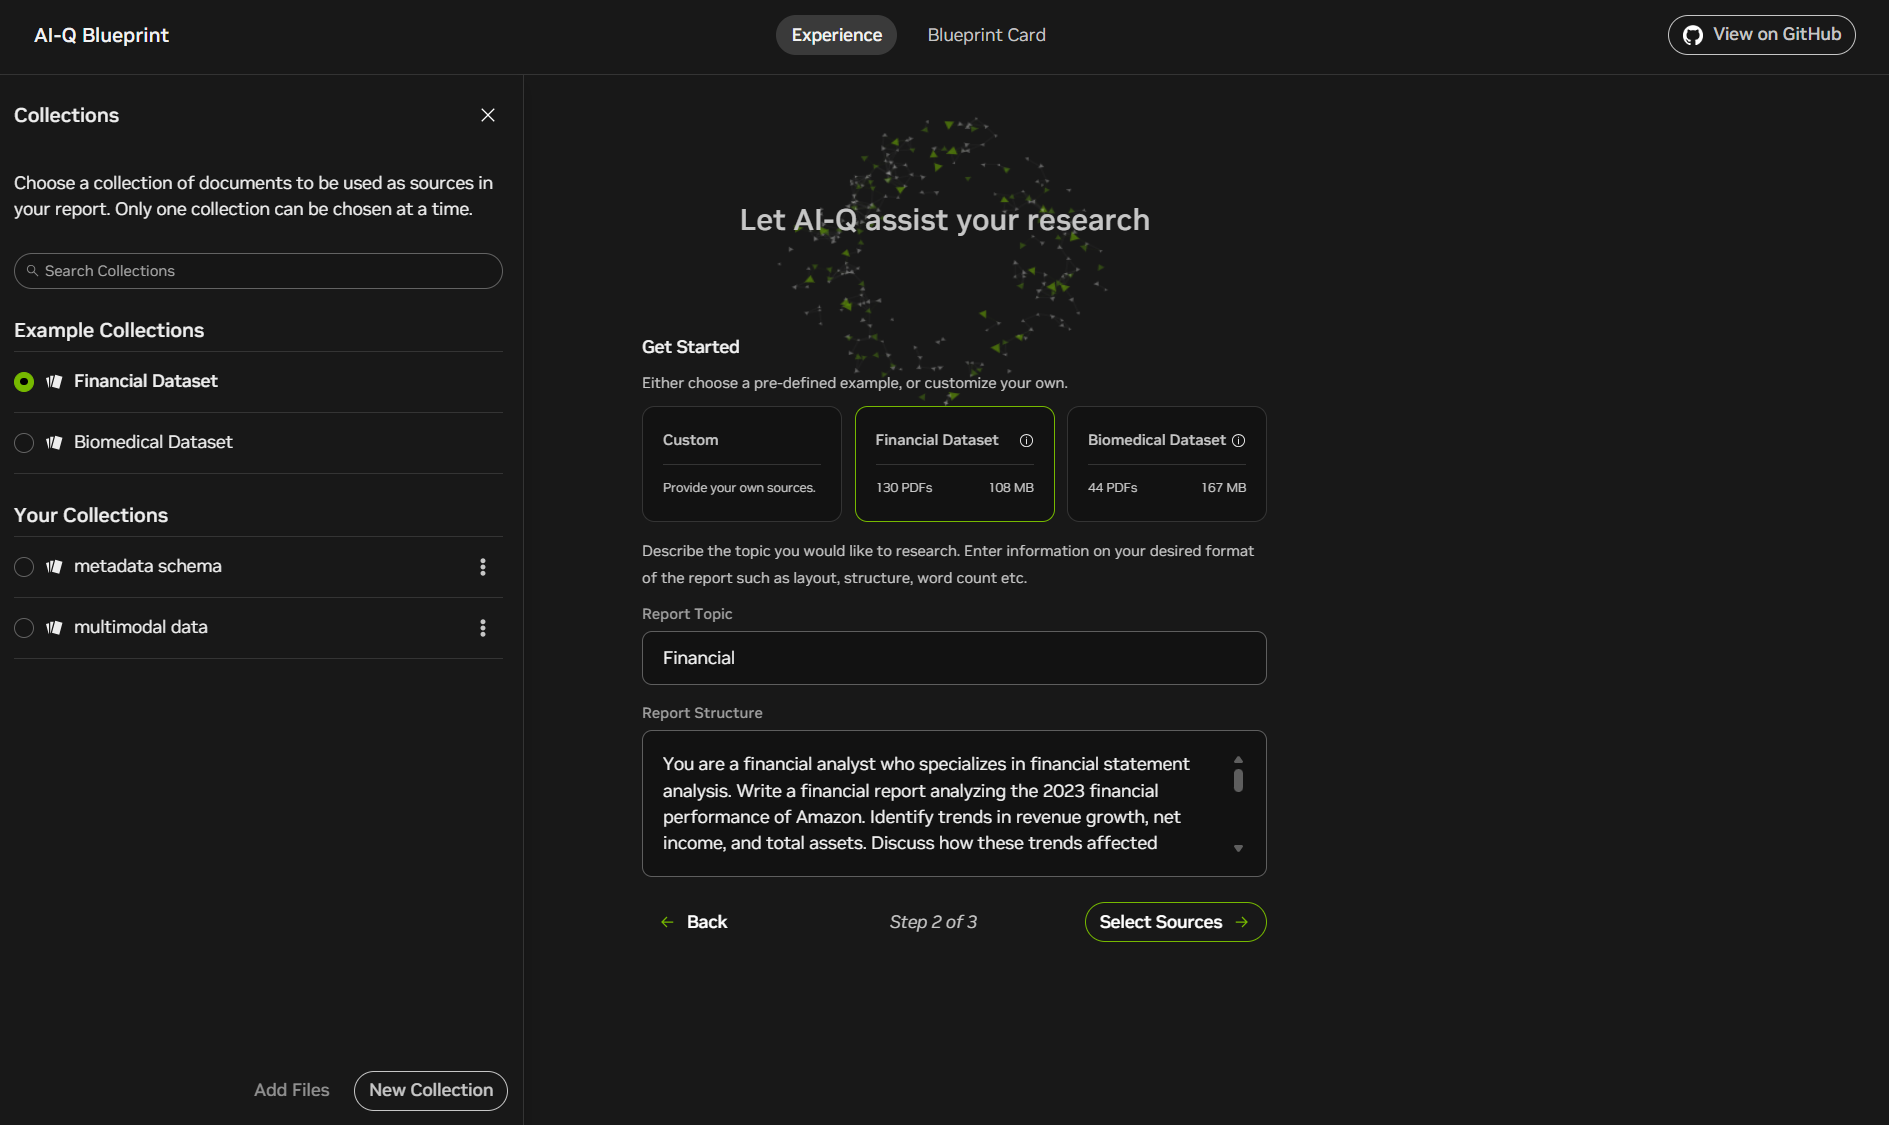

#### 📚 API Documentation (For Developers)

**URL**: `http://<your-ip-or-hostname>:3838/docs`

This is an interactive documentation interface for the backend API. Useful for:
- Understanding the research workflow programmatically
- Integrating AI-Q into your own applications
- Testing API endpoints directly from the browser
- Viewing request/response schemas

---

## 3. Populate the Knowledge Base with Sample Data

Your deep research agent is now running, but it needs data to research! The AI-Q blueprint includes **two curated sample datasets** that demonstrate the system's multi-modal document processing capabilities. In this section, we'll ingest these datasets into the RAG system you deployed in Notebook 03.

### Understanding the Sample Datasets

The blueprint provides two domain-specific collections optimized for testing deep research workflows:

#### 📊 Financial Dataset
- **Content**: Annual reports, SEC filings, earnings transcripts, market analyses
- **Document Types**: PDFs with text, tables, financial charts, and infographics
- **Use Cases**: 
  - Market trend analysis
  - Company performance comparisons
  - Regulatory compliance research
  - Financial forecasting

#### 🧬 Biomedical Dataset  
- **Content**: Research papers, clinical trial reports, drug documentation, medical guidelines
- **Document Types**: Scientific PDFs with complex tables, molecular diagrams, and medical imaging
- **Use Cases**:
  - Literature reviews on medical conditions
  - Drug efficacy research
  - Clinical protocol synthesis
  - Biomedical trend analysis

**Why These Datasets?**

These collections showcase AI-Q's ability to:
- Extract text from complex layouts (multi-column scientific papers)
- Parse structured data (financial tables, clinical trial data)
- Process visual elements (charts, diagrams, infographics)
- Handle domain-specific terminology (financial jargon, medical terms)

### How Document Ingestion Works

When you run the upload command below, here's what happens behind the scenes:

```
1. Document Upload
   └─ Files sent to ingestor-server API
   
2. Multi-Modal Extraction (NV-Ingest)
   ├─ Text extraction from paragraphs
   ├─ Table detection and parsing
   ├─ Image/chart captioning
   └─ OCR for scanned content
   
3. Chunking & Embedding
   ├─ Text split into semantic chunks
   └─ Each chunk converted to vector embedding
   
4. Vector Storage
   └─ Embeddings stored in Milvus with metadata
   
5. Ready for Retrieval!
   └─ AI-Q can now search these documents
```

This process uses the **same document ingestion pipeline** you deployed in Notebook 03, powered by:
- **NV-Ingest**: NVIDIA's multi-modal extraction service
- **NeMo Retriever**: Vision models for page elements, tables, and OCR
- **Embedding NIM**: Converts text to searchable vectors
- **Milvus**: Stores vectors for fast semantic search

### Bulk Upload Utility

The blueprint includes a Docker container that automates the upload of both datasets. This utility:
- Automatically downloads the pre-processed datasets
- Uploads files in batches to handle API rate limits
- Retries failed uploads automatically
- Provides progress updates for each file

**⏱️ Important: This Process Takes Time**

The upload command can take **several minutes to an hour** to complete, depending on:
- Your network speed (downloading datasets)
- NVIDIA API rate limits (for NVIDIA-hosted NIMs)
- Document complexity (tables and images can take longer to process)

**During this time, the system is:**
- Downloading ~150 documents
- Running OCR and table extraction
- Generating vector embeddings for every chunk
- Storing everything in the vector database

You can check progress in the ``RAG Playground`` running on port ``8090``! You should notice new collections getting created and files getting uploaded as the utility works. 

You can also **upload your own documents** through the web interface at `http://<your-ip-or-hostname>:3000` after this initial setup completes!

### Running the Upload

Start by running the Docker upload utility. You'll see progress updates as files are processed:

**Expected Output:**
```
INFO:__main__:Starting upload of 43 files to Biomedical_Dataset
INFO:__main__:Uploading files to Biomedical_Dataset. Elapsed time: 10 seconds
  ...
  ijms-24-12365.pdf: Success
  jci-132-154571.pdf: Success
  ...
INFO:__main__:Starting upload of 92 files to Financial_Dataset
INFO:__main__:Uploading files to Financial_Dataset. Elapsed time: 10 seconds
  ...
  AMZN-Q3-2023-Earnings-Release.pdf: Success
  AMZN-Q4-2023-Earnings-Release.pdf: Success
  ...
```

Run the cell below to start the ingestion process:

In [ ]:
!docker run \
  -e RAG_INGEST_URL=http://ingestor-server:8082/v1 \
  -e PYTHONUNBUFFERED=1 \
  -v /tmp:/tmp-data \
  --network s-fx-40-v1_default \
  nvcr.io/nvidia/blueprint/aira-load-files:v1.2.0

### 3.1 Verify Data Upload Success

**Success Indicators:**

At the end of the upload command, you should see a success output similar to:

```
Upload to collection Financial_Dataset finished with result: 92 documents attempted.
...
...     // Upload status of all files
...
aapl-20220625.pdf: Success

INFO:__main__:Upload to collection Biomedical_Dataset finished with result: 43 documents attempted.
...
...     // Upload status of all files
...
ijms-23-12274.pdf: Success
```

### Troubleshooting Upload Issues

**If you see upload failures:**

#### Common Issue #1: Ingestion Service Errors

**Symptom**: Error appears in the document upload process

```
Input should be 'PENDING' or 'FINISHED' [type=literal_error, input_value='FAILED', input_type=str]
```

**Check the logs**:
```bash
# Check ingestor service
docker logs ingestor-server

# Check document processing service
docker logs compose-nv-ingest-ms-runtime-1
```

**Look for**:
- Connection errors to Milvus (vector database)
- API authentication failures (check NGC_API_KEY is set)
- Memory/resource issues (may need to restart services)

#### Common Issue #2: Rate Limiting (429 Errors)

**Symptom**: Docker logs for the ingestor-server shows `HTTP 429: Rate Limit Exceeded`

**Solution**: This is temporary! NVIDIA's hosted endpoints have rate limits. Simply wait a few minutes and **re-run the upload command**:

```bash
docker run \
  -e RAG_INGEST_URL=http://ingestor-server:8082/v1 \
  -e PYTHONUNBUFFERED=1 \
  -v /tmp:/tmp-data \
  --network s-fx-40-v1_default \
  nvcr.io/nvidia/blueprint/aira-load-files:v1.1.0
```

The utility is **idempotent**—it will skip already-uploaded files and only process what failed. Depending on rate limits, you may need to run this command multiple times for all documents to complete.

```
...
INFO:__main__:Skipping aapl-20230701.pdf because it already exists in the collection Financial_Dataset
INFO:__main__:Skipping aapl-20220625.pdf because it already exists in the collection Financial_Dataset
...
```

#### Common Issue #3: Network Connectivity

**Symptom**: Upload container can't reach ingestor-server

**Solution**: Verify all services are up and running successfully
```bash
docker ps
```

You should see the `ingestor-server` with running and/or healthy status.

**If problems persist**, consult:
- [NVIDIA RAG Blueprint Troubleshooting Guide](https://github.com/NVIDIA-AI-Blueprints/rag/blob/main/docs/troubleshooting.md)
- [AI-Q Research Assistant Troubleshooting Guide](https://github.com/NVIDIA-AI-Blueprints/aiq-research-assistant/blob/main/docs/troubleshooting.md)

### Adding Your Own Documents

Once the sample datasets are loaded, you can add your own documents through the web interface:

1. **Navigate to** `http://<your-ip-or-hostname>:3838/collections` (view collections) or `http://<your-ip-or-hostname>:3000` (add collections)
2. **Click** "Create New Collection" or select an existing collection
3. **Upload files**: Drag and drop PDFs, DOCX, TXT, or images
4. **Wait for processing**: You'll see a progress bar as documents are ingested
5. **Start researching**: Your new documents are immediately searchable!

**Supported File Types:**
- 📄 PDF (with or without text layer)
- 📝 Microsoft Word (.docx)
- 📊 Text files (.txt, .md)
- 🖼️ Images with text (.png, .jpg) - OCR will extract text

Now that your knowledge base is populated, you're ready to conduct deep research!

---

## 4. Conduct Deep Research: A Walkthrough

Now for the exciting part—using your deep research agent! This section walks you through the complete research workflow, from topic selection to final report generation.

### The Deep Research Workflow

The AI-Q Research Assistant guides you through **four distinct phases**:

```
Phase 1: Topic Definition → Phase 2: Plan Review → Phase 3: Research Execution → Phase 4: Report Refinement
```

Let's explore each phase in detail.

### 📝 Phase 1: Define Your Research Topic 

**Step 1.1: Navigate to the Research Interface**

1. Open `http://<your-ip-or-hostname>:3000` in your browser
2. You'll land on the **Home Page** with a prompt input area

**Step 1.2: Choose a Research Template (or Start Fresh)**

The interface provides **two pre-configured research prompts** that work with the sample datasets:

**Option A: Financial Research** 📊
```
Topic: "Financial"
Report Structure:
  "You are a financial analyst who specializes in financial statement analysis. Write a financial report analyzing the 2023 financial performance of Amazon. Identify trends in revenue growth, net income, and total assets. Discuss how these trends affected Amazon's yearly financial performance for 2023. Your output should be organized into a brief introduction, as many sections as necessary to create a comprehensive report, and a conclusion. Format your answer in paragraphs. Use factual sources such as Amazon's quarterly meeting releases for 2023. Cross analyze the sources to draw original and sound conclusions and explain your reasoning for arriving at conclusions. Do not make any false or unverifiable claims. I want a factual report with cited sources."
```

**Option B: Biomedical Research** 🧬
```
Topic: "Biomedical"
Report Structure:
  "You are a medical researcher who specializes in cystic fibrosis. Create a report analyzing how CFTR modulators can be used to restore CFTR protein functions. Include a 150-200 word abstract and a methods, results, and discussion section. Format your answer in paragraphs. Consider all (and only) relevant data. Give a factual report with cited sources."
```

**Option C: Custom Research** ✍️

You can also create your own research topic! Just specify:
- **Report Topic**: Clear, specific research question or area
- **Report Structure**: Outline of sections you want in the final report
- **Target Collections**: Select which document collections to search (Financial, Biomedical, or your own custom collection)

**Example Custom Prompt:**
```
Topic: "Impact of artificial intelligence on healthcare delivery"

Report Structure:
  "I want to see a report structured with the following sections: 
    1. Introduction to AI in Healthcare
    2. Current Applications (Diagnostics, Treatment Planning, Drug Discovery)
    3. Benefits and Cost Savings
    4. Ethical and Privacy Concerns
    5. Implementation Challenges
    6. Recommendations for Healthcare Providers"
```

**Step 1.3: Submit Your Research Request**

1. Enter or select your topic and structure
2. Choose which collections to search (or leave as "All")
3. Toggle **web search** (optional - requires Tavily API key)
4. Click **"Start Research"**

### 🗺️ Phase 2: Review and Approve the Research Plan 

**What Happens Now?**

The AI-Q backend uses the **Nemotron reasoning model** to analyze your request and create a detailed research plan. This typically takes 10-30 seconds.

**Step 2.1: Review the Generated Plan**

You'll see a structured research plan that includes two sections:

1. **Reasoning** - These contain the reasoning tokens as the agent works to generate the detailed research plan
2. **Plan** - These contain the response tokens of the plan the agent created for your query consisting of several subtasks.

Within the **Plan**, each subtask section can be expanded to show

1. **Section** - Which section of the final report the agent wants to use this query for
2. **Rationale** - Reasoning as to why the agent believes it is important to ask this query to accomplish this subtask. 

**Example Plan (Financial Research):**

```
Reasoning

  Okay, let's tackle this. The user wants three search queries to help plan sections of a financial re...
  
Plan

  * Amazon 2023 annual financial report summary

      > Section: Introduction
      > Rationale: Provides an overview of Amazon's 2023 financial highlights to frame the introduction

  * Amazon revenue growth trends 2023 Q1-Q4 comparison

  * Amazon 2023 vs 2022 net income and total assets comparison

  ...

```

**Step 2.2: Human-in-the-Loop: Edit the Plan**

This is the **"human-in-the-loop"** advantage! You can:

✏️ **Add research questions** you want answered  
❌ **Remove questions** that aren't relevant  
🔄 **Reorder sections** to match your priorities  
📝 **Refine the Rationale** to be more specific  

**Why This Matters:**

- Ensures the research aligns with your specific needs
- Prevents wasted time on irrelevant tangents
- Lets you inject domain expertise the AI agent might lack
- Gives you control over the depth and scope of your preferred report

**Step 2.3: Approve the Plan**

Once satisfied with the research plan:
1. Click **"Approve Research Plan"**
2. The backend will begin executing parallel searches

### 🔍 Phase 3: Research Execution 

**What Happens Behind the Scenes?**

AI-Q now orchestrates a sophisticated multi-source research process:

```
┌─────────────────────────────────────────────────────────┐
│                    Research Plan                        │
│         (approved questions and search terms)           │
└──────────────────┬──────────────────────────────────────┘
                   │
        ┌──────────┴──────────┐
        ▼                     ▼
┌──────────────┐      ┌──────────────┐
│  RAG Search  │      │  Web Search  │
│              │      │   (Tavily)   │
│  Queries:    │      │              │
│  - Financial │      │  Queries:    │
│    Dataset   │      │  - Recent    │
│  - Biomedical│      │    articles  │
│    Dataset   │      │  - News      │
└──────┬───────┘      └──────┬───────┘
       │                     │
       └──────────┬──────────┘
                  ▼
         ┌────────────────┐
         │   Synthesis    │
         │ (Nemotron LLM) │
         └────────┬───────┘
                  ▼
         ┌────────────────┐
         │  Draft Report  │
         │ with Citations │
         └────────────────┘
```

**Real-Time Progress Tracking**

The web interface shows you:
- ✅ **Current section** being researched
- 🔍 **Active searches** (RAG and/or web)
- 📄 **Documents retrieved** with relevance scores
- ⏱️ **Research** with real time reasoning token generation

**Example Progress Display:**
```
RAG ANSWER

    Performing RAG search

    QUERY: Amazon 2023 vs 2022 net income and total assets comparison

    ANSWER: Amazon’s net income for the nine months ended September 30, 2023, was $19,801 million compared to a net loss of $3,000 million for the same period in 2022. Total assets as of September 30, 2023, were $462,675 million compared to $486,883 million as of December 31, 2022.

    CITATION: ,amzn-20230930.pdf,,,amzn-20230930.pdf,amzn-20230930.pdf,amzn-20230930.pdf,amzn-20230930.pdf,,amzn-20220331.pdf

    ...

RELEVANCY CHECKER

    Starting Relevancy Check

    ---
    Relevancy score: no  
    Query: Amazon 2023 vs 2022 net income and total assets comparison
    Answer: Amazon’s net income for the nine months ended September 30, 2023, was $19,801 million compared to a net loss of $3,000 million for the same period in 2022. Total assets as of September 30, 2023, were $462,675 million compared to $486,883 million as of December 31, 2022.

  ...

```

**⏱️ Time Expectation:**

Full research typically takes **8-12 minutes** depending on:
- Number of sections in your report
- Complexity of research questions
- Number of documents in your collections
- Whether web search is enabled

### 📋 Phase 4: Report Review and Refinement 

**Step 4.1: View the Generated Report**

Once research completes, you'll see the **full draft report** with:

✨ **Structured sections** matching your approved outline  
📖 **Comprehensive content** synthesized from all sources  
🔗 **Clear citations** referring to specific documents and pages  
📊 **Visual elements** referenced (tables, charts mentioned in sources)  

**Example Report Output:**

```markdown
# Amazon 2023 Financial Performance Report

## Introduction
Amazon's 2023 financial performance demonstrated a notable rebound from the previous year, characterized by robust revenue growth, enhanced profitability, and strategic segment performance. This report analyzes key financial metrics, including revenue trends, net income performance, and total assets growth, to provide insights into the drivers and challenges of Amazon's 2023 financial year.

## Revenue Growth Trends
Amazon achieved an 11% year-over-year (YoY) increase in total net sales, reaching $575 billion in 2023, up from $516 billion in 2022. Quarterly revenue growth was consistent...
```

**Step 4.2: Explore Source Citations**

Under the body of the report is a list of source citations used by the agent for the generation of this report. Take a look a these and see how well-grounded the report is to these RAG and web sources. 

**Step 4.3: Refine Through Q&A**

The report is just the starting point! You can now:

**1. Chat with the Report: Ask Follow-Up Questions and Clarifications**

```
🧒 User: "What is the year-over-year increase in total net sales from 2022 to 2023?"

🤖 AI-Q: [Searches for in the report and the response to the user]
```

```
🧒 User: "In what ways has AWS maintained its market leadership?"

🤖 AI-Q: [Provides evidence from the report to support claim]
```

**2. Edit the Report: Revise and Tune the Final Report**
```
🧒 User: "Make the 'Revenue Growth Trends' section of the report more concise"

🤖 AI-Q: [Revises the desired section to be less verbose]
```

```
🧒 User: "Add a section that has a table for 2023 performance compared to 2022"

🤖 AI-Q: [Conducts new research, adds section to report in markdown table format]
```

**Each refinement**:
- Triggers new searches if needed (RAG + web)
- Updates the report in real-time if desired
- Maintains citation consistency
- Preserves report structure unless told otherwise

**Step 4.4: Export and Share**

Once satisfied with the report, click **"Download Report"**:

   - **PDF**: Formatted document with citations
   - **Markdown**: Plain text for editing


### Advanced Usage Tips

**🎯 Tip 1: Start Broad, Then Narrow**

Begin with a high-level research topic, review the initial report, then use Q&A to drill into specific areas of interest or domain-specific refinements. These human-in-the-loop capabilities enable easy customization at any point in the workflow. 

**🎯 Tip 2: Iterate on the Plan**

Don't be afraid to reject the initial research plan and try again with different wording or structure. The planning phase is quick (< 30 seconds), so experimentation is cheap!

**🎯 Tip 3: Use Web Search Strategically**

Enable web search when you need:
- Current events or recent developments
- Topics not covered in your private documents
- Verification of internal findings against public sources

Disable it when:
- Your documents are comprehensive and up-to-date
- You need faster results (web search adds latency)
- Data privacy is critical (no external API calls)

### What Makes This "Deep" Research?

Let's recap why AI-Q represents a leap beyond traditional search and simple RAG:

| Traditional Search | Basic RAG | AI-Q Deep Research |
|--------------------|-----------|-------------------|
| Keyword matching | Semantic retrieval | **Multi-step reasoning** |
| Single query | One-shot Q&A | **Iterative investigation** |
| List of links or documents | Answer with context | **Comprehensive report** |
| Manual synthesis | Auto-generated response | **Structured, well-cited document** |
| Manual planning | Manual planning | **Human-reviewed, auto-generated plan** |
| Online sources | Your own documents | **Multi-source (RAG + web)** |
| Static results | Static answer | **Refineable through Q&A** |

**The "Deep" in Deep Research means:**

1. **Planning**: Explicit research strategy before execution
2. **Parallelism**: Simultaneous searches across multiple sources
3. **Reasoning**: Step-by-step thinking powered by Nemotron
4. **Human Guidance**: Your expertise shapes the investigation
5. **Synthesis**: Raw findings combined into coherent narratives
6. **Iteration**: Progressive refinement until complete

You've now experienced the full power of agentic AI workflows! 🎉

For additional examples and advanced features, consult the [official AI-Q demo walkthrough](https://github.com/NVIDIA-AI-Blueprints/aiq-research-assistant/blob/main/demo/README.md).

---

## 5. Cleanup: Stopping Services

When you're finished with your deep research session, it's good practice to stop the running services to free up system resources. This section walks you through a clean shutdown process.

### Step 5.1: Stop AI-Q Research Assistant Services

First, stop the AI-Q-specific services (frontend, backend):

**What this command does:**
- Stops the two AI-Q containers (`aira-backend`, `aira-frontend`)
- Removes the stopped containers (due to `down` command)
- Preserves your data (documents, vector embeddings remain in the database)
- Keeps the RAG services running (in case you want to use them standalone)

**When to use this:**
- You're done with deep research but still need RAG functionality
- You want to restart just the AI-Q services without affecting the database

Run the cell below to stop AI-Q services:


In [ ]:
!docker compose -f deploy/compose/docker-compose.yaml --profile aira down

# To also stop the RAG services, uncomment and run the following: 
# !docker compose -f ../rag/deploy/compose/vectordb.yaml down
# !docker compose -f ../rag/deploy/compose/docker-compose-ingestor-server.yaml down
# !docker compose -f ../rag/deploy/compose/docker-compose-rag-server.yaml down

### Step 5.2: Stop RAG Services (Optional)

If you're completely done with the entire system and want to shut down everything, including the RAG infrastructure from Notebook 03, follow these additional steps:

**⚠️ Note**: Only do this if you're finished with both AI-Q AND the RAG system. If you might need RAG for other purposes, leave these services running.

**Stop RAG Orchestration Services:**

These services handle document ingestion and retrieval:

```bash
cd rag  # Navigate to the RAG directory from Notebook 03
docker compose -f deploy/compose/docker-compose-rag-server.yaml down
docker compose -f deploy/compose/docker-compose-ingestor-server.yaml down
```

**Stop Vector Database Infrastructure:**

This stops Milvus and its supporting services (MinIO, etcd, Redis):

```bash
docker compose -f deploy/compose/vectordb.yaml down
```

**⚠️ Data Persistence Note:**

Even after stopping services, your data remains safe! The Docker volumes persist:
- Document embeddings in Milvus volumes
- Object storage in MinIO volumes
- Metadata in etcd volumes

When you restart services later, all your uploaded documents and collections will still be there.

### Step 5.3: Remove Data Volumes (Complete Cleanup)

**Only do this if you want to completely wipe all data and start fresh!**

If you want to remove all data including uploaded documents, vector embeddings, and configurations:

```bash
# Remove cache and volume directories (from the rag directory)
rm -rf deploy/compose/volumes

# Remove Docker volumes explicitly
docker volume rm $(docker volume ls -q | grep nvidia-rag)
```

**This will delete:**
- ❌ All uploaded documents
- ❌ All vector embeddings
- ❌ All collections and metadata
- ❌ Configuration caches

**This will NOT delete:**
- ✅ Docker images (you can reuse them for faster next deployment)
- ✅ The cloned Git repositories (aiq-research-assistant, rag)

### Step 5.4: Verify Clean Shutdown

To confirm all services have been stopped, run:

```bash
docker ps
```

**Expected output:**
```
CONTAINER ID   IMAGE     COMMAND   CREATED   STATUS    PORTS     NAMES
```

An empty list means all containers are stopped successfully.

**To see stopped containers:**
```bash
docker ps -a
```

This shows containers that exist but are not running. You can remove them with:
```bash
docker container prune
```

### Restarting After Shutdown

**To restart just AI-Q** (assuming RAG services are still running):

```bash
cd aiq-research-assistant
docker compose -f deploy/compose/docker-compose.yaml --profile aira up -d
```

**To restart the full stack** (both RAG and AI-Q):

1. Start infrastructure:
   ```bash
   cd rag
   docker compose -f deploy/compose/vectordb.yaml up -d
   ```

2. Start RAG services:
   ```bash
   docker compose -f deploy/compose/docker-compose-ingestor-server.yaml up -d
   docker compose -f deploy/compose/docker-compose-rag-server.yaml up -d
   ```

3. Start AI-Q:
   ```bash
   cd ../aiq-research-assistant
   docker compose -f deploy/compose/docker-compose.yaml --profile aira up -d
   ```

Your data will be preserved, and you can resume where you left off!

---

## 6. (Optional) Local, On-Prem Deployment

The following are instructions for a local, on-prem deployment of this NVIDIA NIM. Due to compute limitations, we will utilize the free NVIDIA-hosted endpoints from above for this course, but these code snippets are provided here as reference for developers interested in spinning up their own endpoints on their own GPU infrastructure. 


## Prerequisites 

1. This blueprint depends on the [NVIDIA RAG blueprint](https://github.com/NVIDIA-AI-Blueprints/rag). The deployment guide includes instructions for deploying RAG using docker compose, but please consult the latest RAG documentation as well. The RAG blueprint requires NVIDIA NIM microservices that are either running on-premise or hosted by NVIDIA, including the Nemo Retriever microservices and LLM, by default Llama 3.3 Nemotron Super 49B. For a self-contained local deployment, 2xH100, 3xA100, or 2xB200 GPUs are required.

2. In addition to the LLM used by RAG, Llama 3.3 Nemotron Super 49B, the AI-Q Research Assistant also requires access to the Llama 3.3 Instruct 70B model. Deploying this model requires an additional 2xB200, 2xH100 GPUs or 4xA100 GPUs.

3. Docker Compose

4. NVIDIA Container Toolkit

5. (Optional) This blueprint supports Tavily web search to supplement data from RAG. A Tavily API key can be supplied to enable this function. 


### Hardware Requirements

*For a self-contained local deployment, including running all RAG services/models locally*
- 4 B200 GPUs **or** 4 H100 GPUs with 80GB of memory each **or** 7 A100 GPUs with 80GB of memory each

*For a deployment using hosted NVIDIA NIM microservices*
- No GPUs are required

### Setup Environment Variables

Start by setting the required environment variables:

```bash
export NVIDIA_API_KEY=nvapi-your-nvidia-api-key
export NGC_API_KEY=$NVIDIA_API_KEY
export TAVILY_API_KEY=your-tavily-api-key
export USERID=$(id -u)
```

Login to the NVIDIA Container Registry:

```bash
echo "${NGC_API_KEY}" | docker login nvcr.io -u '$oauthtoken' --password-stdin
```

Create a model cache directory:

```bash
mkdir -p ~/.cache/model-cache
export MODEL_DIRECTORY=~/.cache/model-cache

### Deploy RAG

Before deploying the AI-Q Research Assistant, deploy RAG by following [these instructions](https://github.com/NVIDIA-AI-Blueprints/rag/blob/main/docs/deploy-docker-self-hosted.md#start-services-using-self-hosted-on-premises-models).

```bash
git clone https://github.com/NVIDIA-AI-Blueprints/rag.git
```

Open the file `rag/deploy/compose/.env` and confirm that all of the values in the section `# ==== Endpoints for using cloud NIMs ===` are commented out. Then source this file:


```bash
source rag/deploy/compose/.env
```

Deploy the RAG NVIDIA NIM microservices, including the LLM. *This step can take up to 45 minutes*.

```bash
docker compose -f rag/deploy/compose/nims.yaml up -d
```

For A100 system, run the following commands 

```bash
export LLM_MS_GPU_ID=1,2

docker compose -f rag/deploy/compose/nims.yaml up -d
```

TIP: You can watch the status with `watch -n 2 'docker ps --format "table {{.Names}}\t{{.Status}}"'`. 

To confirm that the deployment is successful, run `docker ps --format "table {{.Names}}\t{{.Status}}"`, you should see: 

```
   NAMES                                   STATUS

   nemoretriever-ranking-ms                Up 14 minutes (healthy)
   compose-page-elements-1                 Up 14 minutes
   compose-paddle-1                        Up 14 minutes
   compose-graphic-elements-1              Up 14 minutes
   compose-table-structure-1               Up 14 minutes
   nemoretriever-embedding-ms              Up 14 minutes (healthy)
   nim-llm-ms                              Up 14 minutes (healthy)
```

Deploy the Vector DB:

```bash
export VECTORSTORE_GPU_DEVICE_ID=0

docker compose -f rag/deploy/compose/vectordb.yaml up -d
```

To confirm that the deployment was successful, run `docker ps --format "table {{.Names}}\t{{.Status}}"`. In addition to the previously running containers, you should see: 

```
milvus-standalone                Up 2 minutes
milvus-minio                     Up 2 minutes (healthy)
milvus-etcd                      Up 2 minutes (healthy)
```

Deploy the ingestion server:

```bash
docker compose -f rag/deploy/compose/docker-compose-ingestor-server.yaml up -d
```

To confirm that the deployment was successful, run `docker ps --format "table {{.Names}}\t{{.Status}}"`. In addition to the previously running containers, you should see: 

```
compose-redis-1                  Up 3 minutes
compose-nv-ingest-ms-runtime-1   Up 3 minutes (healthy)
ingestor-server                  Up 3 minutes
```

Deploy the RAG server:

```bash
docker compose -f rag/deploy/compose/docker-compose-rag-server.yaml up -d
```

To confirm that the deployment was successful, run `docker ps --format "table {{.Names}}\t{{.Status}}"`. In addition to the previously running containers, you should see: 

```
rag-playground                   Up 4 minutes
rag-server                       Up 4 minutes
```

### Deploy the instruct model

Next deploy the instruct model. *This step can take up to 45 minutes*.

```bash
docker compose -f deploy/compose/docker-compose.yaml --profile aira-instruct-llm up -d
```

For A100 system, run the following commands 

```bash
export AIRA_LLM_MS_GPU_ID=3,4,5,6

docker compose -f deploy/compose/docker-compose.yaml --profile aira-instruct-llm up -d
```

TIP: you can watch the status with `watch -n 2 'docker ps --format "table {{.Names}}\t{{.Status}}"'`. 

To confirm that the deployment was successful, run `docker ps --format "table {{.Names}}\t{{.Status}}"`. In addition to the previously running containers, you should see:

```
aira-instruct-llm                Up 5 minutes (healthy)
```


### Deploy the AI-Q Research Assistant

This step deploys the AIRA backend, AIRA proxy, and the pre-built AIRA demo frontend. The AIRA demo frontend is provided as a pre-built docker container containing a fully functional web application. The source code for this web application is not distributed.

```bash
docker compose -f deploy/compose/docker-compose.yaml --profile aira up -d
```

To confirm that the deployment was successful, run `docker ps --format "table {{.Names}}\t{{.Status}}"`. In addition to the previously running containers, you should see:

```
aira-frontend                    Up 2 minutes
aira-backend                     Up 2 minutes
```

You can then view the web UI at:

```
localhost:3000
```

The backend will be running and visible at:

```
localhost:3838/docs
```


### Add Default Collections

The AI-Q Research Assistant demo web application requires two default collections. One collection supports a biomedical research prompt and contains reports on Cystic Fibrosis. The second supports a financial research prompt and contains public financial documents from Alphabet, Meta, and Amazon. To pre-populate RAG with these two collections, run:

```bash
docker run \
  -e RAG_INGEST_URL=http://ingestor-server:8082/v1 \
  -e PYTHONUNBUFFERED=1 \
  -v /tmp:/tmp-data \
  --network nvidia-rag \
  nvcr.io/nvidia/blueprint/aira-load-files:v1.2.0
```

This command will populate the default collections with sample documents. Note that this process can take up to 60 minutes to complete, during which time manual uploads from the frontend may not work properly.

Troubleshooting tips if the default collection creation fails: 


1. If you did not deploy RAG via docker compose, you will need to replace these values in the docker run command above:
  - `http://ingestor-server:8082/v1`: replace with your RAG ingestor server address
  - remove the line `--network nvidia-rag`

2. If you get an error that the zip file is not a valid zip file

  Install git LFS for your platform, eg `sudo apt-get install git-lfs` and then run: 

  ```bash
  git lfs install
  git lfs pull
  ```



### Stopping all services

To stop all services, run the following commands in order:

1. Stop the AI-Q Research Assistant services:
```bash
docker compose -f deploy/compose/docker-compose.yaml --profile aira down
```

2. Stop the instruct model:
```bash
docker compose -f deploy/compose/docker-compose.yaml --profile aira-instruct-llm down
```

3. Stop the RAG services:
```bash
docker compose -f rag/deploy/compose/docker-compose-rag-server.yaml down
docker compose -f rag/deploy/compose/docker-compose-ingestor-server.yaml down
docker compose -f rag/deploy/compose/vectordb.yaml down
docker compose -f rag/deploy/compose/nims.yaml down
```

4. Remove the cache directories used by the RAG vector database and minio service:
```bash
rm -rf rag/deploy/compose/volumes/minio
```

Tip: If you retain these directories, the collections you created will remain the next time you start the services.

To verify all services have been stopped, run:
```bash
docker ps
```

---

## 🎓 Summary and Congratulations!

**Congratulations!** You have successfully completed the **NVIDIA AI-Q Deep Research Assistant Blueprint** DLI course! Let's recap your incredible journey:

### What You've Accomplished

Throughout this three-notebook course, you've built and deployed a complete enterprise-grade AI research system:

#### Reasoning Foundational Concepts 🧠
- ✅ Deployed NVIDIA Nemotron reasoning models
- ✅ Understood AI agents and agentic workflows
- ✅ Explored reasoning tokens and their impact on accuracy
- ✅ Used NVIDIA-hosted endpoints via OpenAI-compatible APIs

#### Knowledge Ingestion and Retrieval 📚
- ✅ Built a complete RAG (Retrieval-Augmented Generation) pipeline
- ✅ Deployed vector databases and document ingestion services
- ✅ Processed multi-modal documents (text, tables, images)
- ✅ Implemented semantic search with embedding models

#### Deep Research Agent 🔬
- ✅ Deployed the AI-Q Research Assistant Blueprint
- ✅ Orchestrated agentic workflows with human-in-the-loop
- ✅ Conducted multi-source research (RAG + web)
- ✅ Generated comprehensive, cited research reports
- ✅ Iterated and refined reports through conversational Q&A

---

### Key Concepts You've Mastered

**1. Deep Research vs. Traditional Search**

You now understand why deep research represents a paradigm shift:
- Multi-step planning with human oversight
- Parallel searches across private and public sources
- Reasoning-powered synthesis into structured reports
- Iterative refinement through Q&A

**2. Agentic AI Workflows**

You've experienced how AI agents differ from simple chatbots:
- Autonomous task decomposition
- Tool usage (RAG, web search, reasoning models)
- Human-in-the-loop decision points
- Persistent context across multi-step workflows

**3. Hybrid Deployment Architecture**

You've deployed a production-ready system using:
- NVIDIA-hosted NIMs for GPU-intensive workloads
- Local infrastructure for data sovereignty
- Docker Compose for service orchestration
- Microservices architecture for scalability

**4. Multi-Modal Document Understanding**

You've leveraged NVIDIA's NeMo Retriever to:
- Extract text from complex layouts
- Parse tables and structured data
- Process images and charts
- Handle domain-specific terminology


---

### Real-World Applications

The skills you've learned apply to numerous enterprise use cases:

**Research & Development:**
- Literature reviews across massive document collections
- Patent analysis and prior art searches
- Competitive intelligence gathering

**Financial Services:**
- Market research reports
- Regulatory compliance investigations
- Risk assessment documentation

**Healthcare & Life Sciences:**
- Clinical literature synthesis
- Drug interaction research
- Treatment protocol analysis

**Legal:**
- Case law research
- Contract analysis
- Due diligence investigations

**Corporate Strategy:**
- Market entry analysis
- Vendor evaluation reports
- Technology landscape assessments

---

### Next Steps: Extending Your Knowledge

**1. Customize for Your Domain**

- Upload your organization's documents
- Fine-tune prompts for your specific use cases
- Adjust report structures to match your needs

**2. Explore Local Deployment**

For production environments requiring full data sovereignty:
- Deploy all NIMs on-premises (see Appendix sections in all notebooks)
- Configure high-availability setups
- Implement enterprise authentication and access controls

**3. Integrate Into Your Workflows**

Use the API endpoints to:
- Embed research capabilities in your applications
- Automate periodic research reports
- Build custom UIs tailored to your users

**4. Advanced Agentic Patterns**

Explore more complex agent behaviors:
- Multi-agent collaboration (multiple specialized agents)
- Tool creation (teach agents to use new APIs)
- Long-running research tasks with checkpoints

**5. Contribute to the Community**

- Share your use cases on NVIDIA Developer Forums
- Contribute improvements to the blueprints on GitHub
- Join the NVIDIA AI Enterprise community

---

### Resources for Continued Learning

**NVIDIA Resources:**
- [NVIDIA AI Enterprise](https://www.nvidia.com/en-us/data-center/products/ai-enterprise/)
- [NVIDIA NIM Microservices](https://www.nvidia.com/en-us/ai/)
- [NVIDIA API Catalog](https://build.nvidia.com/)
- [NeMo Agent Toolkit Documentation](https://docs.nvidia.com/nemo/)

**Blueprint Repositories:**
- [AI-Q Research Assistant GitHub](https://github.com/NVIDIA-AI-Blueprints/aiq-research-assistant)
- [RAG Blueprint GitHub](https://github.com/NVIDIA-AI-Blueprints/rag)
- [NVIDIA Blueprints Collection](https://github.com/NVIDIA-AI-Blueprints)

**Community:**
- [NVIDIA Developer Forums](https://forums.developer.nvidia.com/)
- [NVIDIA Discord Community](https://discord.gg/nvidia)
- [NVIDIA AI Webinars](https://www.nvidia.com/en-us/events/)


---

### Final Thoughts

You've not just deployed a demo—you've built production-ready infrastructure for **autonomous AI research agents**. The architecture patterns, deployment strategies, and agentic workflows you've learned represent the cutting edge of enterprise AI.

**The future of AI is agentic**, and you're now equipped to build systems that:
- Think step-by-step through complex problems
- Coordinate multiple tools and data sources
- Collaborate with humans for better outcomes
- Scale to handle real-world research demands

**Thank you** for completing this course. We can't wait to see what you build! 

---

### Feedback and Support

We're constantly improving these learning materials. If you have:
- **Questions**: Post on [NVIDIA Developer Forums](https://forums.developer.nvidia.com/)
- **Issues**: Report on the GitHub repositories
- **Feedback**: Share your thoughts to help us improve

**Happy Learning!** 🎉 

<a href="https://www.nvidia.com/dli"> <img src="images/nvidia_header.png" style="margin-left: -30px; width: 300px; float: left;"> </a>